# Basic pandas

In this notebook, we will learn the most useful pandas ideas for data science and machine learning.

You will practice:
- creating DataFrames
- selecting and filtering rows
- working with columns
- grouping and summarizing data
- reading from and saving to CSV files

## What is pandas?

pandas is a Python library for working with tabular data.

A table in pandas is called a **DataFrame**.

A single column in a DataFrame is called a **Series**.

In [1]:
import pandas as pd

## Create a simple DataFrame

We start with a small example table so we can see the basic structure clearly.

In [2]:
data = {
    "name": ["cat_1", "dog_1", "cat_2", "dog_2"],
    "label": ["cat", "dog", "cat", "dog"],
    "score": [0.91, 0.12, 0.85, 0.33]
}

df = pd.DataFrame(data)
print(df)

    name label  score
0  cat_1   cat   0.91
1  dog_1   dog   0.12
2  cat_2   cat   0.85
3  dog_2   dog   0.33


In [3]:
# check how many rows and columns we have

print("Shape:", df.shape)

Shape: (4, 3)


In [4]:
# see the column names

print("Columns:", df.columns)

Columns: Index(['name', 'label', 'score'], dtype='str')


In [5]:
# check what type each column is

print(df.dtypes)

name         str
label        str
score    float64
dtype: object


## Select columns

In pandas, we can access one column or multiple columns easily.

In [6]:
# grab just one column — gives back a Series

print(df["label"])

0    cat
1    dog
2    cat
3    dog
Name: label, dtype: str


In [7]:
# grab two columns at once — gives back a DataFrame

print(df[["name", "score"]])

    name  score
0  cat_1   0.91
1  dog_1   0.12
2  cat_2   0.85
3  dog_2   0.33


## Select rows

We often want only some rows, not the entire table.

In [8]:
# first two rows only

print(df.head(2))

    name label  score
0  cat_1   cat   0.91
1  dog_1   dog   0.12


In [9]:
# grab a row by its position (0-indexed)

print(df.iloc[1])

name     dog_1
label      dog
score     0.12
Name: 1, dtype: object


## Filtering rows

Filtering means keeping only rows that satisfy a condition.
This is one of the most important pandas skills for machine learning.

In [10]:
# keep only the cat rows

cat_rows = df[df["label"] == "cat"]
print(cat_rows)

    name label  score
0  cat_1   cat   0.91
2  cat_2   cat   0.85


In [11]:
# keep rows where score is above 0.5

high_score_rows = df[df["score"] > 0.5]
print(high_score_rows)

    name label  score
0  cat_1   cat   0.91
2  cat_2   cat   0.85


## Add or modify columns

pandas makes it easy to create new columns from existing ones.

In [12]:
# add a boolean column — True if score is high

df["high_score"] = df["score"] > 0.5
print(df)

    name label  score  high_score
0  cat_1   cat   0.91        True
1  dog_1   dog   0.12       False
2  cat_2   cat   0.85        True
3  dog_2   dog   0.33       False


In [13]:
# scale score to 0-100

df["score_scaled"] = df["score"] * 100
print(df)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
1  dog_1   dog   0.12       False          12.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0


## Sorting

Sorting is useful when we want to rank examples by a score.

In [14]:
# sort by score, highest first

sorted_df = df.sort_values("score", ascending=False)
print(sorted_df)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0
1  dog_1   dog   0.12       False          12.0


## Grouping and summarizing

Grouping helps us compute summaries for each class.
This is useful when checking balance between cat and dog examples.

In [15]:
# average score per label

group_mean = df.groupby("label")["score"].mean()
print(group_mean)

label
cat    0.880
dog    0.225
Name: score, dtype: float64


In [16]:
# count rows per label

group_count = df.groupby("label").size()
print(group_count)

label
cat    2
dog    2
dtype: int64


## Read and write CSV files

We often store predictions, labels, and metadata in CSV files.

In [17]:
# save to csv

df.to_csv("example.csv", index=False)
print("Saved example.csv")

Saved example.csv


In [18]:
# read it back

df_loaded = pd.read_csv("example.csv")
print(df_loaded)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
1  dog_1   dog   0.12       False          12.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0


# Standard EDA Flow for Tabular Data

EDA means **Exploratory Data Analysis**.

EDA can be applied to a wide range of problems and data types; however, this tutorial will focus solely on tabular data.

Before building any model, we should understand the table carefully:
- how big it is
- what each column means
- whether there are missing values
- whether categories are balanced
- whether there are outliers
- whether the numerical columns look reasonable

Good EDA helps us avoid mistakes later.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# make plots a bit bigger and add grid lines
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## Step 1: Load the data

In a real project, the first step is usually to read a CSV file or load a table from a database.

For this tutorial, we will use a small example DataFrame so you can change the data to explore further.

In [20]:
# sample dataset with numeric and categorical columns
# has a missing value and a duplicate row on purpose

df = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5, 6, 6, 7, 8],
    "age": [18, 19, 18, 50, 19, np.nan, np.nan, 20, 21],
    "study_hours": [2.5, 3.0, 1.0, 4.5, 2.0, 5.0, 5.0, 10.0, np.nan],
    "score": [72, 80, 85, 91, 68, 95, 95, 15, 88],
    "major": ["CS", "Math", "CS", "Physics", "Math", "CS", "CS", "CS", "Math"]
})

df

,student_id,age,study_hours,score,major
0,1,18.0,2.5,72,CS
1,2,19.0,3.0,80,Math
2,3,18.0,1.0,85,CS
3,4,50.0,4.5,91,Physics
4,5,19.0,2.0,68,Math
5,6,NaN,5.0,95,CS
6,6,NaN,5.0,95,CS
7,7,20.0,10.0,15,CS
8,8,21.0,NaN,88,Math


## Step 2: Check the shape and preview the first rows

This tells us:
- how many rows and columns there are
- what the data looks like at a glance
- whether the column names make sense

In [21]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
display(df.head())

Shape: (9, 5)
Columns: ['student_id', 'age', 'study_hours', 'score', 'major']

First few rows:


,student_id,age,study_hours,score,major
0,1,18.0,2.5,72,CS
1,2,19.0,3.0,80,Math
2,3,18.0,1.0,85,CS
3,4,50.0,4.5,91,Physics
4,5,19.0,2.0,68,Math


In [22]:
# get a quick overview of the dataframe
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   9 non-null      int64  
 1   age          7 non-null      float64
 2   study_hours  8 non-null      float64
 3   score        9 non-null      int64  
 4   major        9 non-null      str    
dtypes: float64(2), int64(2), str(1)
memory usage: 492.0 bytes
None


## Step 3: Check column types and non-missing counts

This helps us see:
- which columns are numeric
- which columns are categorical
- where missing values may exist

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   9 non-null      int64  
 1   age          7 non-null      float64
 2   study_hours  8 non-null      float64
 3   score        9 non-null      int64  
 4   major        9 non-null      str    
dtypes: float64(2), int64(2), str(1)
memory usage: 492.0 bytes


## Step 4: Clean missing values and duplicate rows

Real-world data is often messy.

Two common issues are:
- **Missing values** (NaN)
- **Duplicate rows**

We usually:
1. Detect them
2. Decide how to handle them
3. Remove or fix them

For this tutorial, we will:
- drop duplicate rows
- remove rows with missing values

In practice, you may choose more advanced strategies (e.g., filling missing values instead of dropping).

In [24]:
# check before we clean anything
print("\nBefore cleaning shape:", df.shape)

print("\nRemaining missing values:")
print(df.isna().sum())

print("\nRemaining duplicates:", df.duplicated().sum())


Before cleaning shape: (9, 5)

Remaining missing values:
student_id     0
age            2
study_hours    1
score          0
major          0
dtype: int64

Remaining duplicates: 1


In [25]:
# drop duplicates first
df_clean = df.drop_duplicates()

# then drop rows with missing values
df_clean = df_clean.dropna()

print("\nAfter cleaning shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isna().sum())

print("\nRemaining duplicates:", df_clean.duplicated().sum())

# use .copy() so df is a fresh independent object
df = df_clean.copy()


After cleaning shape: (6, 5)

Remaining missing values:
student_id     0
age            0
study_hours    0
score          0
major          0
dtype: int64

Remaining duplicates: 0


## Step 5: Summary statistics

Use summary statistics to understand the distribution of numeric columns.

For categorical columns, use value counts to check the class balance.

In [26]:
print("Numeric summary:")
display(df.describe())

print("\nCategorical summary:")
display(df["major"].value_counts())

Numeric summary:


,student_id,age,study_hours,score
count,6.000000,6.00000,6.000000,6.00000
mean,3.666667,24.00000,3.833333,68.50000
std,2.160247,12.75931,3.235223,27.51545
min,1.000000,18.00000,1.000000,15.00000
25%,2.250000,18.25000,2.125000,69.00000
50%,3.500000,19.00000,2.750000,76.00000
75%,4.750000,19.75000,4.125000,83.75000
max,7.000000,50.00000,10.000000,91.00000



Categorical summary:


major
CS         3
Math       2
Physics    1
Name: count, dtype: int64

## Step 6: Look at one variable at a time

An EDA workflow may include simple plots to inspect the distribution of one variable:
- histograms for numeric columns
- bar charts for categorical columns

These plots can reveal skew, imbalance, and outliers.

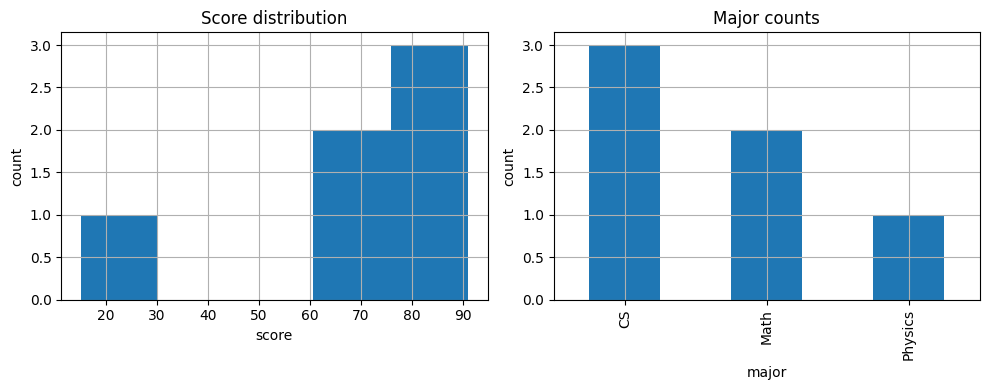

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# histogram for score
axes[0].hist(df["score"].dropna(), bins=5)
axes[0].set_title("Score distribution")
axes[0].set_xlabel("score")
axes[0].set_ylabel("count")

# bar chart for major
df["major"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Major counts")
axes[1].set_xlabel("major")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## Step 7: Compare variables to each other

Now we look at the correlations between columns.

For tabular data, some common questions are:
- Does A relate to B? (*numeric* vs *numeric*)
- Are some categories in column C associated with higher values in column D? (*categorical* vs *numeric*)

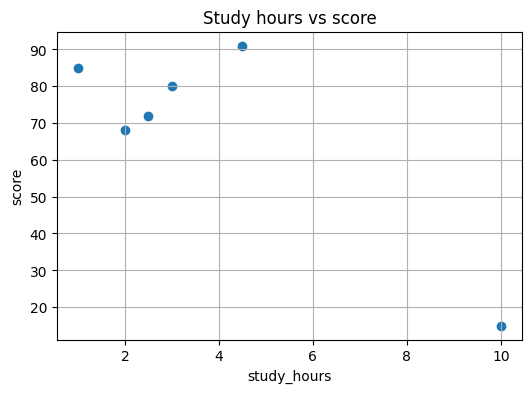

In [28]:
# scatter plot — study hours vs score
plt.figure(figsize=(6, 4))
plt.scatter(df["study_hours"], df["score"])
plt.title("Study hours vs score")
plt.xlabel("study_hours")
plt.ylabel("score")
plt.show()

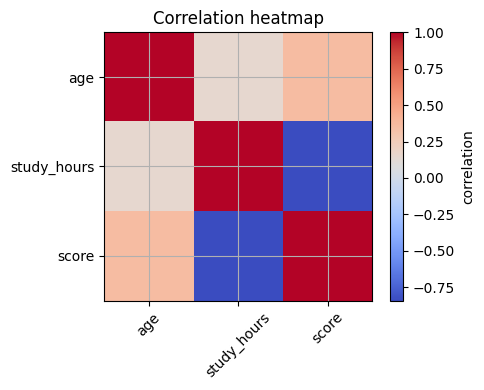

,age,study_hours,score
age,1.000000,0.150197,0.355476
study_hours,0.150197,1.000000,-0.842520
score,0.355476,-0.842520,1.000000


In [29]:
# correlation matrix for numeric columns
numeric_df = df[["age", "study_hours", "score"]]
corr = numeric_df.corr()

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

display(corr)

## Step 8: Detect outliers with box plots

A **box plot** is one of the best tools to detect outliers.

It shows:
- median (middle value)
- quartiles (spread of the data)
- potential outliers (points far away from the rest)

Outliers are usually values that are much larger or smaller than the majority of the data.

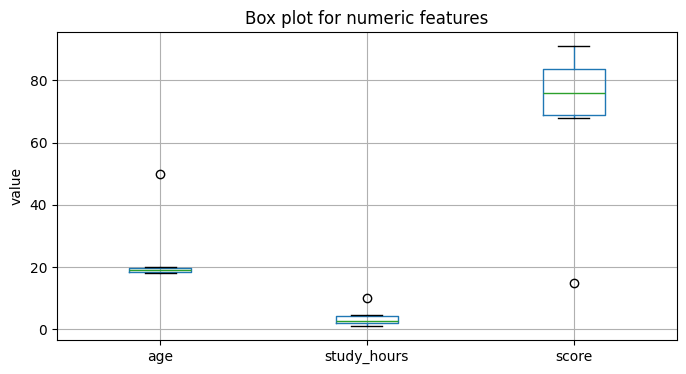

In [30]:
# box plot for all numeric columns
numeric_cols = ["age", "study_hours", "score"]

plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()

plt.title("Box plot for numeric features")
plt.ylabel("value")
plt.show()

## How to read the box plot

- The **box** shows the middle 50% of the data (interquartile range)
- The **line inside the box** is the median
- The **whiskers** extend within 1.5 × IQR from Q1 and Q3, showing variability outside the middle 50%.
- Points outside the whiskers are **potential outliers**

If you see points far away from the box, investigate them.

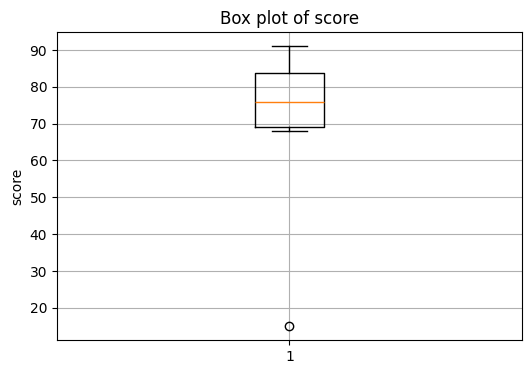

In [31]:
# zoom in on score alone
plt.figure(figsize=(6, 4))
plt.boxplot(df["score"].dropna())

plt.title("Box plot of score")
plt.ylabel("score")
plt.show()

In [32]:
# find outliers in score using the IQR rule
Q1 = df["score"].quantile(0.25)
Q3 = df["score"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# anything outside the bounds counts as an outlier
outliers = df[(df["score"] < lower_bound) | (df["score"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nPotential outliers:")
display(outliers)

Lower bound: 46.875
Upper bound: 105.875

Potential outliers:


,student_id,age,study_hours,score,major
7,7,20.0,10.0,15,CS


## Why plotting matters - a Datasaurus Dozen example

The Datasaurus Dozen is a famous reminder that different datasets can have very similar summary statistics, even though their shapes are completely different.

That means:
- mean may look the same
- standard deviation may look similar
- correlation may look similar

But the plot can tell a very different story.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# datasaurus data embedded directly so it works anywhere
_data = {'away': {'x': [60.6986, 48.301, 18.9403, 44.8891, 56.9002, 23.1338, 81.6767, 19.1569, 88.9873, 22.9291, 82.486, 87.2123, 93.3657, 79.1621, 77.3582, 66.3987, 77.3197, 25.7642, 57.8854, 56.1378, 83.6058, 52.0239, 45.8072, 66.1651, 36.3171, 26.1815, 53.2302, 48.3511, 33.6056, 44.4009, 44.3114, 41.1996, 45.3571, 69.8595, 38.7501, 90.9086, 88.3078, 53.4728, 41.2689, 57.8348, 82.8848, 67.207, 79.3513, 57.6178, 65.6334, 38.0524, 73.7915, 31.1924, 70.5839, 83.8575, 25.5682, 64.1504, 22.6077, 73.0573, 21.7595, 89.8752, 25.9926, 91.7104, 79.0707, 62.4946, 77.6099, 78.6092, 90.6822, 35.2707, 62.2061, 22.6039, 64.2933, 28.7033, 60.196, 60.7944, 52.2788, 56.8105, 76.1139, 78.9396, 54.3723, 62.9675, 89.4989, 24.5787, 24.3683, 22.0167, 67.6291, 48.4887, 76.9457, 68.6985, 41.691, 86.8693, 76.0026, 36.6428, 44.1354, 40.1552, 27.6089, 26.8227, 89.8902, 50.0323, 45.6656, 73.3749, 59.2394, 89.8912, 77.4241, 53.3496, 45.1088, 93.9305, 72.4208, 91.0956, 24.4783, 83.0427, 65.9659, 24.7537, 62.0606, 69.8877, 15.9842, 51.3454, 81.032, 38.6287, 51.6838, 50.3851, 39.1542, 88.4754, 77.5035, 23.8471, 94.7628, 85.336, 37.7127, 81.9517, 23.5136, 94.9284, 68.2548, 67.01, 22.2353, 86.7627, 17.32, 34.2662, 26.4418, 77.1414, 30.8563, 87.8511, 67.5015, 17.893, 15.4344, 19.1326, 63.474, 79.1185], 'y': [23.8553, 84.9409, 5.7232, 80.0964, 92.7795, 77.2108, 69.8121, 83.798, 4.0151, 20.1782, 12.4924, 50.4531, 74.5188, 63.0012, 85.1131, 15.5213, 73.4621, 19.3041, 27.0759, 70.9905, 98.0205, 61.1544, 5.45, 61.6309, 4.2351, 88.4146, 70.9578, 17.3128, 9.1721, 18.3533, 98.0027, 45.8561, 78.4081, 63.6408, 57.2413, 14.513, 94.6024, 30.1343, 57.8017, 69.9776, 64.9233, 94.0594, 14.8439, 50.8353, 40.4034, 47.4169, 11.9218, 13.4095, 27.8076, 30.4705, 42.7903, 61.0988, 63.4629, 41.1811, 40.8783, 21.7629, 58.8306, 31.7041, 3.606, 41.84, 47.4133, 22.5593, 57.2458, 56.5772, 70.2002, 64.7948, 65.2433, 31.6214, 78.7432, 54.9144, 43.1418, 62.6012, 36.0657, 51.2739, 73.6706, 88.6403, 92.1057, 50.3633, 52.0275, 79.987, 31.4451, 83.7382, 49.4142, 11.5857, 7.2059, 84.1993, 5.5568, 28.0611, 33.413, 17.2994, 31.3893, 74.2693, 1.4683, 82.7173, 85.6548, 37.2262, 15.3613, 60.084, 11.9673, 36.4919, 95.8429, 99.5464, 77.2105, 31.0962, 68.7665, 70.5406, 38.7842, 64.0889, 1.0728, 20.9058, 52.5088, 16.3751, 16.5907, 83.6304, 98.9133, 55.5969, 83.907, 99.0322, 14.1596, 44.8246, 39.2573, 8.0049, 75.533, 43.3779, 46.9327, 15.0673, 18.0927, 90.7104, 4.4649, 23.2852, 29.2059, 49.0198, 58.6445, 49.329, 8.4115, 24.3667, 84.3588, 63.7589, 64.9149, 67.0203, 76.2903, 5.8108]}, 'bullseye': {'x': [17.0032, 35.9911, 52.0976, 17.4796, 64.4136, 69.2648, 74.7385, 56.326, 63.3156, 46.6852, 18.3002, 22.9961, 67.3997, 94.6444, 16.2643, 59.6067, 75.0807, 81.142, 58.6164, 64.5933, 70.738, 83.7173, 24.7832, 89.0946, 17.0814, 81.896, 21.1392, 30.5703, 15.3115, 50.6205, 41.7487, 28.2794, 51.0872, 47.1897, 76.4129, 86.4504, 67.2054, 24.9528, 38.6313, 88.0655, 22.0988, 47.5485, 90.4004, 91.0532, 47.8963, 68.3918, 51.5396, 75.2768, 17.5265, 26.5326, 64.1359, 33.6042, 68.2842, 43.0978, 85.9316, 80.5408, 54.427, 76.8316, 36.691, 54.5408, 30.7986, 83.8709, 80.8454, 87.172, 85.1982, 91.7677, 33.2669, 89.5459, 60.6971, 48.7996, 59.8299, 42.4082, 38.0842, 34.3051, 21.5942, 54.7252, 86.0209, 65.4122, 56.6781, 49.2874, 52.1521, 31.7422, 80.8349, 30.8706, 72.3298, 75.7988, 60.9895, 84.0341, 38.284, 85.5294, 73.3528, 78.9, 68.1664, 82.7074, 94.4479, 48.613, 80.1133, 74.5664, 51.2296, 89.1559, 46.5541, 60.2373, 23.4754, 33.062, 82.2557, 46.7242, 46.5267, 34.6785, 54.3288, 79.4654, 86.6131, 20.6092, 60.9857, 52.3819, 64.1425, 50.7821, 46.8916, 52.7505, 61.5599, 55.0787, 52.7716, 80.4268, 74.6518, 42.3103, 79.0462, 83.2921, 27.2794, 61.6146, 37.825, 74.1338, 34.1028, 68.7123, 35.41, 55.8915, 90.8917, 45.5046, 85.0591, 93.9556, 84.9881, 28.2693, 80.5727, 17.572], 'y': [39.3302, 87.0733, 68.8752, 53.274, 38.7864, 81.2297, 70.9558, 46.8405, 89.2484, 22.9948, 17.0392, 64.2804, 97.1994, 24.7257, 24.967, 13.9499, 86.0564, 22.6398, 50.3179, 99.0872, 1.2141, 55.6486, 51.2289, 80.7447, 35.5282, 41.0341, 16.7938, 74.0815, 78.4709, 13.6663, 39.3457, 89.2905, 0.2707, 29.8759, 55.5042, 33.4094, 27.2045, 46.0037, 18.1523, 52.9625, 70.6696, 57.5295, 9.3109, 84.4409, 17.4978, 76.4812, 36.0565, 78.2761, 20.6273, 18.6662, 49.7026, 3.2936, 22.5297, 72.4012, 83.7383, 8.0785, 88.2078, 79.7517, 86.9684, 69.8429, 67.4153, 52.5093, 65.2787, 91.911, 10.0522, 31.5764, 7.2455, 94.4805, 44.5265, 67.5344, 84.112, 99.1, 16.1782, 79.9513, 88.7423, 4.8875, 75.4091, 35.4725, 64.8597, 51.4048, 25.9742, 13.5221, 11.6947, 10.3323, 63.779, 35.1411, 21.6633, 69.1885, 68.685, 53.9168, 93.4958, 38.5414, 83.5863, 7.5139, 73.9831, 98.8447, 84.6598, 57.9665, 62.6766, 35.329, 67.9485, 77.0395, 99.8228, 49.2463, 6.1304, 59.5858, 11.9024, 24.4765, 32.878, 73.103, 18.3808, 16.5753, 4.4964, 87.324, 69.3505, 3.9946, 2.8292, 55.8674, 28.2534, 59.6726, 43.4604, 92.3313, 28.7809, 67.9145, 5.4054, 95.5861, 98.0757, 73.9075, 46.5212, 21.9993, 81.2516, 73.6354, 22.1954, 45.1215, 46.2799, 82.6411, 68.3845, 64.3168, 64.9827, 27.047, 37.1711, 4.5662]}, 'circle': {'x': [75.3656, 82.3964, 84.5243, 17.9144, 59.4952, 32.3015, 83.8277, 66.8718, 48.6178, 30.0483, 42.1219, 71.3022, 31.3488, 22.4866, 86.0423, 76.1368, 30.9836, 38.3849, 92.7656, 71.6548, 63.8418, 39.6103, 38.93, 18.1619, 73.2785, 18.454, 15.3886, 73.3596, 90.9099, 75.5202, 52.7312, 53.8836, 49.8909, 40.9715, 56.7371, 49.4921, 62.8534, 86.8496, 94.6008, 21.2995, 45.7747, 29.4565, 43.1696, 37.9978, 28.963, 76.1261, 54.7031, 88.5396, 17.6074, 20.3582, 47.2619, 21.4222, 36.0184, 93.8824, 31.7168, 30.8494, 60.8913, 54.8399, 61.4351, 45.1388, 81.141, 26.0864, 49.2714, 70.1809, 84.4589, 44.5657, 60.4196, 20.5312, 28.6255, 20.5311, 73.2305, 38.0448, 72.8996, 20.3119, 84.0038, 81.8424, 22.1143, 16.9005, 19.5031, 83.2904, 33.7763, 58.8619, 49.0995, 78.642, 54.1119, 55.0529, 94.1274, 27.0104, 81.4563, 19.14, 53.2119, 85.9068, 68.2171, 69.8172, 36.0654, 48.486, 44.3265, 56.7155, 51.9782, 41.1519, 39.4384, 35.0682, 44.2038, 26.9953, 84.7683, 63.1696, 25.7029, 70.5087, 82.8133, 34.0029, 27.048, 15.6894, 18.78, 75.9801, 93.9749, 18.5904, 74.8457, 20.749, 62.3706, 75.486, 43.7364, 15.8748, 62.6151, 94.2996, 35.6094, 30.1593, 24.9141, 59.4204, 62.7156, 78.3817, 75.2459, 86.4033, 79.4618, 34.7814, 59.4702, 38.793, 41.3828, 89.5555, 69.5517, 92.9672, 48.353, 57.995], 'y': [48.7115, 10.7287, 23.6702, 52.7636, 6.7374, 93.1462, 12.3844, 19.7981, 76.5321, 9.6935, 90.0278, 72.5701, 6.8621, 69.1847, 63.1629, 75.7349, 82.8198, 71.8351, 58.6176, 32.2463, 69.7274, 95.6972, 58.7522, 66.4345, 43.7128, 75.6121, 99.7667, 16.0389, 20.2405, 53.9438, 48.1375, 57.157, 4.9074, 40.4276, 58.2978, 58.5191, 65.7334, 72.0216, 64.1547, 79.0243, 62.4761, 53.7508, 60.6196, 10.1193, 27.3157, 52.74, 87.2987, 67.9052, 9.0408, 59.2275, 22.1738, 73.4017, 82.7441, 59.3456, 59.1363, 33.8591, 44.625, 86.4108, 72.332, 51.9754, 36.8232, 5.038, 14.3007, 19.3025, 37.3384, 94.4144, 50.5153, 23.484, 10.575, 33.8306, 81.5731, 38.3343, 77.2506, 80.2705, 11.0821, 60.866, 95.9096, 40.2138, 5.0944, 92.3303, 88.3666, 52.2141, 55.2253, 21.1741, 81.9451, 49.86, 3.3878, 68.3015, 95.0496, 82.915, 27.7198, 5.3325, 94.0351, 93.7063, 53.2415, 64.2317, 46.26, 41.9765, 11.9448, 9.6753, 23.2732, 83.6641, 14.5832, 22.6699, 54.8614, 21.5131, 16.3207, 56.3316, 36.8093, 62.6159, 91.2205, 15.0993, 91.3434, 90.249, 82.9088, 63.1286, 62.0147, 63.9213, 69.0496, 1.6482, 95.8093, 58.5604, 78.1466, 37.7282, 1.2397, 50.9735, 50.719, 43.6989, 33.9717, 24.9826, 52.7545, 37.5278, 96.9932, 17.2927, 31.9666, 29.396, 54.3309, 49.928, 64.374, 95.0002, 28.5221, 69.2772]}, 'dino': {'x': [76.9165, 50.1103, 83.6878, 70.7894, 22.5342, 93.0498, 75.8912, 77.8851, 25.2491, 51.0309, 44.6638, 89.1412, 66.5092, 80.8209, 50.4731, 33.1791, 59.3668, 20.1054, 81.2105, 65.5332, 75.647, 43.3621, 92.6558, 86.4497, 77.2707, 30.5711, 52.3377, 18.5043, 27.3432, 69.6439, 74.581, 92.4008, 41.066, 44.6368, 52.5645, 30.1577, 25.3937, 53.0564, 33.1527, 68.5851, 49.9722, 81.6143, 71.0212, 39.9893, 81.5808, 79.3811, 45.9983, 38.0662, 69.5996, 26.1802, 30.9927, 15.589, 77.954, 68.1881, 71.4132, 77.4583, 51.7133, 60.4993, 26.1838, 24.1624, 68.4722, 52.6877, 60.2189, 76.1999, 65.7775, 59.2864, 59.7366, 39.316, 17.4654, 49.9374, 32.1668, 47.6823, 83.2722, 33.7152, 19.6642, 37.5107, 38.4875, 67.9533, 59.5626, 77.7119, 68.1451, 47.5109, 80.1216, 28.3578, 16.817, 22.2038, 72.7887, 51.9502, 27.9017, 55.0836, 27.185, 70.7056, 50.6925, 45.4817, 39.121, 65.4226, 43.945, 22.012, 24.4405, 91.9518, 87.6865, 70.9766, 36.2696, 92.5341, 77.3001, 72.3512, 50.9489, 36.7793, 22.7113, 87.2082, 51.4621, 31.1891, 39.4765, 61.3376, 29.1418, 83.5291, 75.6816, 72.557, 49.5674, 65.1847, 61.7278, 66.9877, 21.7555, 48.2646, 18.3291, 54.5193, 41.3889, 26.5619, 23.2722, 62.0116, 28.6474, 89.0096, 61.4849, 42.7496, 62.2732, 16.8243, 91.6847, 53.5843, 77.6188, 21.6184, 53.9327, 54.2566], 'y': [93.7826, 57.1728, 47.3489, 26.6976, 33.1569, 52.0672, 43.8911, 2.1612, 82.6292, 89.6161, 14.0249, 55.4036, 10.8576, 67.224, 28.1234, 65.9423, 72.6995, 76.8647, 10.7741, 91.6012, 23.0214, 3.7413, 55.4852, 37.0922, 82.979, 80.8251, 31.7139, 95.2899, 29.0918, 51.5057, 25.5965, 93.6044, 16.4608, 4.4911, 43.5097, 99.2376, 89.1677, 74.8608, 89.0792, 89.3447, 51.8858, 31.5929, 77.2012, 66.1661, 37.3658, 9.4467, 74.679, 26.2461, 93.6813, 24.0971, 12.2758, 83.1113, 15.3284, 17.9268, 59.9383, 87.4562, 19.6435, 31.0324, 77.7405, 97.1826, 50.0741, 14.3898, 1.3936, 22.9656, 13.1822, 67.7659, 12.1833, 50.633, 69.4262, 58.1117, 19.9776, 80.4125, 71.5407, 73.8984, 13.1058, 12.3754, 92.7563, 39.7578, 30.0949, 48.8584, 66.2864, 95.5623, 28.6446, 92.4808, 2.4859, 55.5198, 63.3975, 10.5897, 14.034, 41.9114, 96.6232, 59.6043, 93.3023, 80.4361, 46.7382, 78.4763, 1.7837, 10.9144, 82.9429, 79.6817, 23.2641, 53.077, 60.6016, 86.7739, 60.3107, 41.2572, 37.4184, 42.5882, 65.1931, 86.7491, 45.3897, 24.784, 23.6662, 74.6014, 81.6569, 10.5278, 6.6559, 59.4434, 14.6173, 82.4664, 31.0335, 14.3872, 92.097, 16.5532, 28.472, 15.3613, 11.549, 2.1148, 5.5395, 17.4641, 5.3382, 59.1144, 68.0715, 39.363, 31.7991, 50.4526, 87.5005, 85.1132, 4.3475, 18.1498, 23.6745, 24.9388]}, 'dots': {'x': [93.985, 27.0479, 22.0722, 68.9356, 42.1789, 20.6996, 53.0244, 75.3017, 37.8098, 41.8038, 82.656, 56.6058, 82.4186, 50.7112, 91.238, 67.0636, 24.2719, 85.8074, 54.1412, 26.3311, 27.2152, 70.0027, 18.7898, 37.9275, 26.183, 50.2862, 48.1483, 56.7501, 37.3709, 17.5635, 64.1509, 44.8974, 67.1068, 23.6934, 16.1022, 34.8635, 51.5238, 46.5258, 79.8242, 45.227, 57.4353, 62.4812, 16.7465, 56.2107, 42.5865, 48.7024, 23.023, 77.6256, 90.3923, 16.7815, 63.1098, 76.1075, 37.7846, 78.0044, 65.5884, 89.333, 93.4804, 18.3877, 50.595, 58.759, 26.7395, 41.9029, 94.0118, 16.2984, 51.2006, 82.4124, 40.9121, 53.3839, 93.2437, 52.9901, 25.4737, 19.1377, 90.6333, 36.2648, 55.3251, 22.2561, 48.8924, 89.4084, 55.193, 92.6908, 35.7069, 55.3636, 83.7625, 50.8602, 37.359, 83.438, 46.1912, 57.4579, 93.1222, 29.9187, 39.1121, 17.4856, 46.347, 31.0147, 69.4028, 29.5057, 68.985, 36.078, 43.4174, 42.9089, 72.3401, 52.3207, 43.9039, 83.2098, 60.7561, 32.1065, 87.0073, 42.412, 18.1184, 54.568, 24.915, 34.0773, 74.7689, 25.4601, 79.5555, 89.9526, 63.5226, 71.8287, 72.0869, 94.4246, 42.3231, 28.0285, 56.5334, 57.66, 29.233, 64.0488, 16.13, 89.2135, 36.1659, 18.1648, 23.66, 34.2199, 36.9125, 17.6248, 37.3484, 30.4353, 45.2897, 45.8134, 42.1206, 41.2339, 22.1785, 17.0164], 'y': [20.2114, 75.6649, 99.081, 92.8526, 50.4219, 53.1824, 31.4582, 77.3939, 76.4757, 84.4272, 89.5505, 43.4349, 76.6876, 80.6399, 30.846, 92.9242, 9.4342, 99.4269, 77.0091, 9.3271, 65.623, 3.4179, 77.0187, 79.9223, 60.241, 85.686, 9.7883, 27.5924, 41.4178, 4.2458, 44.8216, 26.5213, 39.2735, 42.5103, 87.9412, 27.0341, 89.3743, 42.5971, 32.7808, 50.2512, 41.7743, 25.7372, 50.2679, 15.1802, 35.193, 56.579, 41.3408, 82.3912, 25.6722, 96.9772, 78.4722, 96.7593, 83.8137, 14.2104, 52.646, 16.9979, 81.8227, 58.4162, 26.3449, 92.9599, 11.5186, 56.3862, 72.1041, 5.8849, 59.7856, 81.5901, 6.7527, 51.2243, 25.8557, 66.2924, 11.8677, 93.7051, 89.4729, 18.5974, 32.3266, 58.7635, 71.8062, 44.2656, 15.6291, 10.4151, 99.9765, 45.5352, 87.2532, 48.2376, 92.2358, 8.7759, 11.4019, 92.9632, 94.7493, 31.4717, 35.5165, 45.245, 41.6162, 19.0045, 89.8375, 25.3308, 70.5272, 6.7156, 3.8751, 65.373, 33.9016, 65.5459, 9.4021, 94.9851, 74.8514, 87.6267, 13.6471, 32.0161, 36.8344, 53.7173, 29.6868, 6.0631, 36.8878, 25.4549, 38.5921, 19.696, 26.1896, 62.6952, 38.8154, 34.5383, 53.3906, 77.1861, 37.8868, 58.7519, 96.6203, 52.198, 90.9798, 79.3673, 5.8719, 42.9099, 69.8318, 98.6712, 45.8376, 9.2785, 56.2009, 12.6564, 75.152, 50.7677, 72.3431, 86.9362, 62.8948, 61.2439]}, 'h_lines': {'x': [44.3287, 58.1622, 42.0765, 82.5583, 53.6058, 76.4902, 83.1612, 55.3833, 87.7642, 61.9699, 83.0219, 42.2473, 54.9054, 57.5129, 23.3984, 46.8842, 88.387, 65.4666, 29.2005, 42.1085, 30.3282, 16.9859, 89.1968, 50.8566, 39.6028, 62.8782, 15.5852, 37.2418, 71.2427, 65.7016, 93.5445, 64.6286, 53.2005, 75.9146, 87.2662, 72.6557, 92.0569, 77.5604, 84.3441, 24.1283, 73.5931, 50.2071, 59.2483, 67.3282, 92.5852, 93.7662, 38.0583, 73.7003, 74.9987, 42.7194, 24.9096, 18.2758, 77.1875, 54.176, 93.8432, 52.1979, 93.2334, 47.9261, 78.4946, 21.7855, 59.4369, 79.1648, 88.9761, 80.8066, 17.9577, 44.8162, 18.8959, 23.7426, 69.0245, 72.0607, 76.8977, 84.2365, 74.1545, 79.0697, 18.9171, 33.7628, 64.7518, 83.65, 15.36, 56.1703, 69.183, 17.3686, 47.1084, 86.6508, 68.729, 34.0127, 83.2225, 42.8425, 83.2676, 38.9155, 62.2256, 46.7552, 36.986, 85.9246, 30.0075, 21.7849, 42.3542, 72.4111, 79.5945, 94.8995, 38.709, 47.6354, 25.9457, 60.9898, 94.8064, 71.0705, 62.617, 46.3895, 88.2239, 54.7533, 25.7494, 44.2303, 20.3733, 31.1583, 16.4135, 51.2624, 65.7632, 42.4634, 48.6305, 91.7367, 75.157, 58.2685, 37.7633, 86.7597, 33.8078, 41.0274, 87.7252, 57.3634, 74.3854, 62.2596, 67.2751, 38.9507, 34.3098, 40.7994, 27.4353, 84.9451, 37.6598, 59.9192, 78.358, 77.7059, 50.0709, 53.1006], 'y': [99.4702, 67.4597, 81.4638, 90.2554, 78.759, 18.5179, 56.2171, 10.1894, 65.2922, 95.5349, 51.2732, 43.2972, 3.5843, 95.9775, 10.3003, 4.1079, 24.6067, 6.553, 45.5118, 51.6088, 31.257, 5.096, 11.16, 38.4504, 6.0528, 69.819, 20.7021, 30.2072, 39.4126, 41.661, 0.1661, 11.207, 86.2765, 0.1233, 50.8167, 48.9502, 33.3094, 43.1327, 78.0581, 84.1204, 26.0349, 32.249, 24.2483, 47.9863, 68.3258, 22.8253, 33.0736, 93.0385, 4.8569, 46.077, 71.1558, 15.0454, 4.7374, 13.8205, 91.8823, 0.926, 18.8322, 3.1284, 11.0629, 62.0149, 24.1639, 56.9212, 59.0195, 84.9435, 0.4741, 85.3369, 61.9119, 16.2743, 77.2937, 85.5492, 25.4263, 91.8794, 45.4457, 60.3424, 98.465, 36.1536, 81.3159, 31.8399, 79.9214, 60.0734, 21.6356, 41.4026, 31.7636, 7.8108, 2.9835, 34.6479, 1.9034, 16.5488, 72.5183, 70.8091, 73.858, 31.7153, 89.0019, 59.3831, 12.6026, 14.3719, 69.3095, 17.2944, 50.7293, 99.1774, 0.4008, 1.658, 99.3085, 58.4639, 12.691, 89.7302, 88.038, 53.62, 62.1792, 27.3187, 5.052, 59.4568, 29.4755, 66.3621, 83.6245, 1.8161, 59.5714, 23.1281, 87.3888, 25.3665, 61.077, 55.3541, 39.6167, 67.7621, 72.577, 56.6938, 75.8422, 98.3417, 41.9272, 51.4583, 1.247, 79.6029, 52.023, 40.7961, 9.4072, 88.9656, 39.5007, 68.2582, 14.9374, 96.155, 17.8442, 19.9542]}, 'high_lines': {'x': [52.9146, 93.9303, 22.5046, 47.99, 85.0431, 37.7241, 78.0234, 45.6227, 93.3983, 85.6824, 39.1056, 76.6154, 41.9485, 63.509, 67.6785, 81.3676, 16.9561, 32.6126, 71.9534, 60.0819, 54.6484, 19.4168, 42.8621, 84.208, 17.4714, 46.7149, 90.6119, 19.0705, 74.9765, 35.609, 84.3287, 74.6854, 85.8564, 32.274, 57.5034, 77.3416, 34.656, 33.4597, 17.1746, 91.6812, 71.8014, 65.8448, 74.5196, 57.529, 53.0907, 50.9626, 66.2351, 31.1228, 86.0447, 79.9402, 42.9651, 61.2887, 26.2822, 92.7877, 87.2314, 88.7518, 41.573, 28.5308, 31.9418, 22.2001, 24.6089, 20.7044, 94.1858, 20.9246, 25.6034, 81.1804, 61.4192, 76.9534, 65.473, 85.574, 66.0774, 56.77, 72.02, 50.7914, 42.6851, 52.4122, 28.5771, 78.7257, 35.8563, 27.2825, 34.7082, 82.3656, 41.4161, 69.884, 83.5128, 21.2196, 76.202, 39.6132, 32.3298, 70.1121, 87.7837, 38.6015, 60.5067, 38.1867, 59.3428, 64.749, 63.8268, 64.8837, 25.8064, 70.4832, 68.98, 69.607, 20.9256, 50.7471, 47.7228, 21.9369, 32.7894, 50.277, 74.4325, 33.965, 81.38, 58.6639, 75.8337, 52.8045, 54.9355, 64.5776, 89.2376, 54.345, 57.2926, 63.1598, 74.0012, 20.748, 56.255, 53.5273, 88.7348, 54.4805, 52.4656, 91.976, 51.0461, 29.4708, 32.3533, 22.615, 15.0455, 49.5557, 76.5394, 73.6773, 17.5719, 60.5986, 27.3427, 90.2861, 28.3892, 65.1311], 'y': [32.6238, 64.1561, 41.2259, 75.9643, 23.0679, 90.5792, 50.021, 75.6093, 84.973, 99.8829, 22.3946, 28.6892, 25.0433, 26.2871, 58.2445, 99.3523, 99.0278, 52.6773, 63.9027, 85.9971, 93.2933, 20.3861, 52.8542, 83.2837, 30.3202, 43.9809, 98.5621, 98.5047, 90.6107, 79.8448, 26.9131, 32.085, 54.7283, 56.0777, 50.5503, 63.667, 40.8323, 74.9174, 33.355, 33.0677, 12.7226, 18.8712, 85.0521, 44.6282, 22.7868, 75.9341, 55.3981, 2.1156, 31.6361, 17.7001, 65.5873, 27.5031, 6.4947, 5.4935, 58.1727, 2.1723, 84.8792, 15.5397, 60.6566, 44.4688, 44.2852, 7.1797, 80.2752, 89.3052, 1.1017, 17.8604, 90.3904, 54.9494, 15.004, 20.279, 65.9986, 72.4817, 59.9427, 95.3148, 49.4064, 30.0272, 47.7233, 35.9666, 22.4416, 4.5963, 35.2212, 71.1409, 1.8438, 43.9179, 64.4009, 61.0404, 77.6648, 81.052, 71.1706, 10.2798, 47.5022, 60.3406, 24.5566, 4.2552, 22.359, 45.4894, 41.393, 17.6667, 82.4416, 92.5687, 20.1348, 92.9573, 1.7861, 92.4962, 95.1929, 1.2052, 76.3019, 97.0202, 90.5902, 97.071, 55.0324, 7.8156, 84.9789, 61.3828, 61.4737, 41.7254, 57.1842, 15.358, 73.977, 7.5017, 72.9781, 84.8978, 47.2469, 50.983, 31.2214, 96.9459, 73.3124, 36.8989, 17.4807, 21.958, 46.3922, 94.2568, 73.4146, 21.5244, 85.9561, 37.8201, 85.1722, 24.17, 61.8661, 92.667, 25.7894, 69.2927]}, 'slant_down': {'x': [30.2336, 30.4406, 58.3391, 25.3102, 70.1118, 90.5158, 49.1436, 87.0884, 22.8653, 18.4366, 72.7095, 75.8817, 82.4447, 19.5454, 77.1526, 45.1231, 39.267, 28.8419, 94.6813, 20.0931, 81.1606, 66.1596, 73.8064, 71.9374, 83.6748, 29.7034, 15.066, 62.8823, 43.3087, 24.903, 29.8911, 41.5399, 20.6187, 19.5531, 88.2821, 39.9682, 93.5785, 92.1494, 26.4057, 72.1939, 63.0644, 70.2518, 22.6953, 30.0848, 21.1311, 63.3307, 93.9273, 68.7588, 71.8609, 93.7668, 69.2409, 18.2145, 84.3604, 44.1743, 15.3491, 55.5787, 89.9612, 35.5865, 54.3211, 28.9022, 19.6154, 21.4436, 73.1609, 84.126, 26.4639, 38.0655, 30.6024, 17.1485, 59.2745, 70.9938, 66.8302, 46.0443, 59.4008, 22.5279, 27.3443, 89.5436, 75.9206, 88.8191, 88.3344, 66.9514, 89.2591, 48.3363, 15.2893, 20.0057, 23.759, 22.6283, 43.1362, 71.1017, 78.2519, 62.2171, 26.7149, 74.8321, 43.3842, 16.0395, 37.4471, 41.448, 36.9396, 79.9496, 75.7941, 70.6442, 26.1204, 79.6267, 69.1741, 30.587, 66.8475, 53.6809, 50.148, 23.9699, 56.4643, 22.9945, 28.1403, 25.6037, 91.3287, 37.7892, 43.4163, 40.7664, 86.86, 60.0373, 88.5328, 38.994, 24.1868, 59.4975, 42.643, 79.1525, 85.3539, 52.8059, 92.7087, 59.241, 36.6736, 54.118, 17.9848, 79.3201, 23.1148, 39.6999, 60.2253, 18.438, 21.3454, 70.6893, 20.7422, 53.1666, 42.0957, 33.2464], 'y': [18.8779, 76.3411, 95.1542, 14.018, 95.9681, 59.4763, 64.166, 70.9926, 70.4119, 81.9811, 48.3469, 53.3359, 32.3827, 10.5258, 66.464, 3.361, 27.5635, 9.423, 19.0727, 63.8731, 62.8477, 42.1055, 9.0172, 43.3374, 35.2745, 72.0459, 57.9027, 49.1566, 48.6982, 96.6297, 75.6294, 49.698, 47.9223, 2.6479, 94.2509, 31.9174, 25.5939, 99.9409, 71.869, 4.7364, 6.1885, 2.5502, 59.9619, 7.1565, 93.3388, 93.6907, 54.6054, 61.6639, 29.1894, 6.3973, 73.746, 10.1786, 8.5558, 31.1223, 1.2466, 43.4036, 70.7681, 80.1349, 60.4307, 84.6874, 40.6502, 84.8772, 50.6473, 22.3036, 94.4146, 27.4971, 2.6201, 24.2674, 36.6688, 35.135, 52.4668, 88.3127, 29.2338, 52.0771, 34.0139, 82.1773, 15.7602, 10.351, 50.2995, 67.1888, 79.5525, 58.9625, 77.385, 39.271, 3.2868, 11.6099, 3.8723, 32.8944, 49.5491, 35.6317, 56.0599, 48.0609, 67.7943, 66.6962, 31.8064, 34.6214, 58.5148, 59.6432, 31.47, 33.0318, 69.4045, 64.7411, 13.5051, 44.1042, 89.2706, 3.6306, 85.5164, 16.3178, 50.7249, 42.4336, 1.0129, 91.5397, 45.4925, 95.4268, 28.6744, 86.6276, 92.239, 55.6832, 20.2678, 68.5247, 54.8978, 94.453, 43.9272, 26.8514, 13.8287, 69.8634, 97.411, 2.8344, 74.0445, 92.693, 7.4782, 11.017, 69.1957, 64.7963, 6.8827, 83.4423, 52.3424, 90.7197, 87.7991, 81.2508, 51.5899, 25.1711]}, 'slant_up': {'x': [77.9553, 49.6399, 50.0591, 34.6285, 31.7542, 62.0258, 33.6042, 20.1367, 76.4006, 45.1176, 45.4188, 49.5055, 80.2036, 40.667, 75.6429, 90.1636, 67.8695, 49.5345, 74.8232, 51.6318, 48.1542, 57.0227, 40.4178, 23.34, 48.1882, 24.9086, 47.8353, 59.5547, 89.4569, 17.8978, 64.7167, 51.6188, 16.6209, 34.9639, 24.4788, 32.3435, 36.9656, 47.1045, 57.3232, 15.0792, 27.9495, 22.4853, 58.9739, 41.326, 58.8718, 32.7459, 16.9383, 90.3094, 23.6646, 25.1487, 26.7237, 93.5021, 64.4128, 63.8232, 93.9359, 22.0751, 92.9601, 31.3211, 64.8457, 48.6067, 45.7161, 89.4995, 26.9382, 94.7655, 45.33, 66.902, 92.4325, 19.6081, 88.8291, 60.4249, 71.3518, 26.9347, 57.671, 68.8811, 51.4998, 27.3988, 34.5295, 83.3514, 17.7577, 71.709, 94.9512, 15.5986, 27.8837, 68.9315, 19.7993, 62.1832, 69.72, 62.0517, 44.2148, 70.7826, 62.5436, 31.611, 60.0508, 85.5526, 68.3467, 52.7433, 40.7267, 21.8709, 34.5702, 15.8949, 93.9301, 32.7986, 80.1901, 28.4916, 37.6881, 48.4622, 40.9525, 78.8681, 91.6155, 85.0236, 27.2862, 77.1351, 26.8358, 88.0705, 56.4303, 41.9105, 27.562, 15.9447, 34.8358, 88.1216, 78.781, 92.5835, 23.0609, 62.3743, 35.572, 58.4353, 40.6364, 37.6772, 60.9076, 29.6655, 52.5307, 67.065, 25.2546, 89.4475, 55.458, 80.5622, 67.3124, 71.8001, 72.2905, 85.008, 64.0884, 37.2574], 'y': [9.951, 60.6251, 6.6353, 24.1293, 6.0707, 54.8888, 16.0338, 61.0407, 79.0865, 82.1881, 30.9544, 54.8955, 56.3011, 47.2887, 65.5114, 21.0087, 97.9243, 9.808, 82.9221, 59.4096, 24.4855, 74.5675, 8.4481, 77.4418, 58.9985, 11.075, 7.9506, 75.0836, 29.2936, 88.9302, 76.2073, 69.819, 27.8606, 70.8945, 94.8148, 9.156, 32.6163, 23.4672, 39.325, 74.2333, 47.4243, 57.0731, 31.4155, 14.1289, 26.6934, 85.968, 60.2417, 37.7989, 78.9906, 6.4457, 25.3891, 23.0103, 98.5365, 70.6099, 61.7786, 0.4985, 18.431, 63.5541, 37.9719, 92.428, 76.4724, 44.7384, 74.9515, 97.5404, 46.0981, 64.2526, 91.8665, 24.8675, 88.6558, 9.7545, 64.8448, 78.2838, 61.4606, 49.5535, 61.7347, 15.1664, 21.5571, 26.9899, 59.7779, 44.1901, 24.4476, 88.2809, 37.3922, 44.6032, 40.9701, 18.1943, 73.1627, 44.8458, 1.6257, 96.4014, 81.5764, 72.3559, 86.9092, 90.6807, 33.749, 61.0959, 60.8808, 26.73, 22.1952, 11.3907, 65.9314, 78.0919, 76.0953, 31.6275, 20.526, 45.3614, 54.6813, 91.9087, 87.4823, 91.6058, 85.0262, 96.4581, 46.55, 4.7473, 8.3562, 39.0276, 25.7687, 16.9941, 95.3204, 19.542, 95.9379, 76.0839, 64.0946, 67.6019, 33.1474, 64.6427, 18.6692, 93.7705, 30.1793, 25.5187, 71.1163, 65.6449, 45.1299, 63.2446, 15.9493, 67.3328, 27.0611, 27.2836, 16.218, 33.2377, 33.1251, 45.4179]}, 'star': {'x': [71.3871, 53.6351, 51.5123, 45.9073, 43.9279, 46.3205, 22.1803, 21.1949, 77.3896, 50.6858, 89.4548, 63.9777, 17.8141, 27.6019, 31.4656, 93.0589, 32.4963, 56.2605, 89.8942, 93.1754, 33.9088, 18.9294, 27.2881, 20.0663, 30.6099, 60.4856, 87.9959, 57.9775, 65.0792, 31.1494, 79.0467, 64.4231, 84.1309, 90.9074, 42.8321, 22.2463, 33.0743, 50.0273, 90.6555, 45.2648, 76.6619, 58.2381, 29.6247, 40.6587, 67.2554, 68.8283, 49.7808, 33.2916, 72.7525, 28.5098, 89.9336, 30.0323, 23.585, 54.8118, 56.564, 55.6554, 49.9334, 94.5852, 53.9024, 53.2357, 48.7413, 20.3461, 62.4365, 33.2374, 66.0087, 19.0667, 93.511, 52.5204, 86.7404, 53.0449, 19.8265, 80.7771, 66.8547, 77.5406, 49.2536, 66.0349, 83.4983, 65.4852, 42.8139, 68.0024, 68.7483, 91.847, 44.673, 49.0065, 79.9698, 55.461, 73.9258, 51.7768, 32.2396, 74.6163, 25.4924, 30.8867, 65.146, 74.7816, 86.575, 36.8069, 23.8579, 91.4837, 27.3538, 30.8134, 38.3064, 57.3513, 85.626, 75.8437, 71.6526, 29.0144, 43.6146, 53.2724, 26.7941, 36.8744, 39.6667, 25.1821, 59.0192, 71.4023, 20.5945, 53.4898, 77.5769, 74.8392, 80.2058, 50.8593, 80.6446, 34.2602, 43.8648, 29.1084, 52.3988, 46.3648, 34.2742, 75.1425, 40.1077, 36.8243, 25.4712, 50.1057, 39.2372, 44.5418, 33.8798, 76.0524, 89.4003, 54.8345, 66.4399, 84.3738, 94.9064, 64.0813], 'y': [88.9779, 90.8608, 79.1451, 46.0931, 8.1154, 1.5806, 47.7201, 49.4315, 40.7362, 56.8167, 55.2163, 83.6613, 10.8657, 22.5178, 79.3005, 84.7837, 99.4824, 87.2912, 88.9899, 31.4348, 40.1662, 26.8085, 60.6299, 93.8805, 34.4641, 55.7002, 29.63, 16.98, 19.5186, 5.7945, 94.9294, 40.288, 83.4121, 68.1329, 19.1921, 17.5462, 81.1988, 26.4712, 91.3285, 14.0055, 67.7709, 81.4474, 23.5256, 27.6207, 96.4519, 26.4598, 42.9957, 43.2516, 25.3035, 77.5791, 77.1849, 37.8318, 83.5126, 21.3075, 0.4306, 57.1167, 99.4078, 3.8644, 20.7998, 51.8915, 80.9941, 8.9042, 39.5235, 74.7076, 37.1543, 18.8836, 19.5496, 41.0049, 47.9417, 86.1814, 64.2252, 69.0402, 98.2987, 41.1843, 40.3354, 92.3347, 24.5876, 72.9815, 75.4573, 9.7788, 46.8231, 20.0562, 18.5375, 46.3828, 28.943, 79.606, 90.7605, 80.2721, 26.6031, 27.4134, 25.4728, 13.5038, 94.3798, 40.2048, 22.4689, 84.6671, 39.9195, 3.5117, 16.1942, 63.925, 78.2905, 21.0934, 91.7396, 85.0997, 84.8381, 22.7661, 5.0536, 86.7424, 30.58, 61.8916, 75.9967, 12.8293, 78.0838, 93.8511, 72.8375, 44.1223, 87.6678, 52.7458, 74.4771, 82.0506, 74.9353, 28.7855, 11.7844, 23.8339, 50.2875, 50.5277, 58.2644, 39.5102, 78.6891, 91.3154, 24.6725, 73.6523, 67.7972, 52.309, 18.853, 79.5232, 96.0626, 72.1836, 91.786, 98.4185, 35.2051, 63.8224]}, 'v_lines': {'x': [83.7186, 88.0066, 31.9718, 52.5841, 73.6796, 85.2693, 45.3242, 56.3616, 74.3373, 73.4909, 77.6368, 60.5947, 23.3692, 87.3179, 84.2458, 78.8478, 22.989, 31.3518, 74.488, 16.8512, 93.338, 45.1716, 72.545, 86.0057, 46.5704, 40.5306, 63.6993, 61.4791, 47.7312, 63.142, 89.8305, 52.4112, 30.7394, 45.1765, 46.5286, 25.4887, 28.0297, 69.765, 42.1582, 91.3919, 34.4877, 22.914, 75.2804, 85.4829, 37.2491, 31.167, 29.8613, 56.761, 52.4733, 35.7552, 18.6138, 53.5193, 91.7466, 67.2015, 54.6405, 23.8554, 35.1949, 38.5819, 76.1843, 85.1369, 87.1313, 93.7655, 93.5893, 91.2399, 20.7458, 26.0235, 39.3573, 59.2319, 22.7582, 82.6638, 64.3405, 58.3892, 28.2249, 35.2604, 27.825, 83.1547, 61.7382, 73.8104, 38.6826, 44.7002, 47.3884, 75.8012, 76.7882, 31.5451, 90.3231, 24.6524, 86.6898, 23.0317, 36.1632, 82.7183, 29.3594, 48.0854, 50.9887, 34.6207, 71.8196, 83.1068, 84.966, 42.1458, 57.468, 34.8725, 34.5837, 27.9003, 90.2015, 86.0391, 77.1887, 56.4129, 54.2486, 57.3797, 57.9254, 49.765, 25.5404, 25.0531, 91.18, 53.5625, 91.2564, 28.0862, 59.3533, 31.6174, 35.2548, 17.4044, 24.5163, 88.3479, 40.7226, 63.6503, 52.2011, 47.0361, 57.5509, 29.9791, 94.0883, 80.4646, 74.3292, 52.5007, 27.2302, 88.6533, 42.311, 19.0085, 42.3923, 78.5566, 64.8167, 75.0671, 78.4908, 31.9564], 'y': [92.3783, 43.799, 63.9014, 0.2309, 99.3368, 28.0896, 6.2063, 45.8262, 12.903, 15.2327, 63.2283, 39.2927, 92.1852, 31.9156, 72.618, 46.1099, 65.9951, 59.9695, 47.2784, 95.0061, 34.2714, 17.7236, 67.8094, 84.6008, 4.0254, 44.9633, 89.2488, 74.9619, 99.1808, 53.1414, 65.9996, 30.248, 94.7536, 36.6335, 73.8511, 40.314, 56.1819, 71.9783, 50.8934, 90.7086, 41.9301, 64.7072, 34.2362, 40.8157, 44.005, 12.5807, 9.1724, 66.749, 65.5518, 66.291, 1.9766, 32.6547, 19.781, 77.8151, 86.063, 24.668, 66.7849, 12.9363, 27.5153, 13.8654, 28.3521, 67.4737, 91.0327, 20.2522, 54.2079, 70.1391, 95.2922, 61.006, 25.5107, 62.5478, 32.0491, 97.6128, 39.9676, 68.5428, 2.3228, 40.0061, 87.5108, 61.0227, 44.3943, 93.5937, 85.3984, 32.2216, 54.4548, 48.9824, 63.2203, 33.4111, 24.4205, 91.2672, 92.3874, 84.3323, 97.8204, 74.4992, 76.4667, 76.259, 48.0608, 45.6452, 24.0226, 64.4819, 28.932, 25.7808, 58.5961, 40.9982, 21.8857, 81.6056, 86.057, 16.77, 0.7507, 33.613, 79.7511, 83.9174, 13.8329, 77.4336, 11.5704, 39.0063, 99.861, 19.2591, 15.3964, 42.28, 61.9669, 93.2901, 98.0821, 6.9641, 13.7998, 79.0738, 27.0632, 88.4849, 66.3453, 11.1845, 83.2529, 17.6356, 42.3495, 55.2185, 50.0766, 68.6163, 65.2687, 99.2042, 99.9422, 51.6459, 9.5199, 72.7843, 97.6664, 31.8326]}, 'wide_lines': {'x': [55.478, 23.0649, 67.7077, 25.7182, 55.8938, 19.3506, 38.961, 33.5664, 64.6025, 77.9429, 19.5842, 83.0227, 83.8614, 42.3815, 67.7203, 47.209, 27.3353, 57.293, 21.9088, 85.2778, 88.9432, 80.7291, 60.0022, 59.6079, 93.7686, 34.8321, 21.0759, 59.9553, 41.3028, 40.7871, 15.5668, 62.6992, 36.1227, 30.0287, 18.2346, 44.1489, 85.3175, 41.9337, 69.3259, 75.5238, 41.2481, 80.7313, 70.3504, 59.7394, 15.0794, 17.8073, 94.2693, 77.5827, 90.0052, 87.1843, 16.6354, 78.3478, 51.0917, 78.1647, 15.5373, 38.0559, 75.1059, 78.4417, 64.5772, 39.1005, 39.829, 92.3411, 50.137, 50.77, 59.1866, 47.7602, 59.2137, 49.5868, 81.1372, 87.7241, 89.5688, 60.1437, 50.3719, 71.4192, 82.0659, 60.0386, 70.9985, 74.9783, 69.1115, 74.6907, 31.6916, 54.87, 62.0615, 15.1982, 83.477, 63.802, 25.3309, 80.3086, 72.3646, 75.664, 46.3634, 83.3362, 48.1222, 60.6407, 15.0514, 66.5898, 72.4541, 60.3687, 54.7247, 79.7949, 69.5098, 37.2459, 91.7259, 71.5814, 94.0351, 92.7009, 88.5128, 75.4297, 63.7543, 28.7737, 58.4681, 76.2301, 56.6686, 84.4591, 23.7725, 45.4752, 55.4772, 49.586, 23.6869, 27.2823, 82.0094, 53.7507, 18.8978, 16.3193, 52.878, 28.1503, 71.4101, 78.6259, 33.2637, 62.3742, 27.3556, 39.2866, 86.1036, 58.5278, 85.8711, 33.0198, 41.4019, 52.6762, 53.4064, 94.8118, 24.1556, 83.1572], 'y': [86.3682, 55.3199, 34.4037, 51.9226, 29.2468, 79.9107, 49.8279, 92.5842, 62.2691, 51.4319, 71.1069, 50.3933, 90.4506, 18.4446, 97.3349, 81.2191, 86.0733, 48.2908, 83.7202, 30.6774, 76.1948, 14.045, 30.7052, 44.5733, 32.232, 38.7017, 82.0105, 25.6676, 74.5281, 7.3712, 76.5739, 79.2023, 40.1699, 72.2478, 91.5138, 80.0713, 39.0447, 48.4214, 77.9358, 29.2595, 80.3883, 32.8071, 80.5991, 8.68, 4.4397, 99.7675, 86.9457, 88.2848, 95.128, 43.8316, 28.6836, 13.0025, 50.1209, 22.0048, 93.5551, 0.4003, 14.3197, 24.6476, 19.8957, 22.5778, 65.6048, 32.7512, 61.5024, 89.0258, 60.2557, 69.4533, 36.5503, 15.9738, 32.0584, 96.4283, 62.1811, 27.7511, 45.0915, 83.5513, 66.8444, 56.0653, 88.5163, 67.244, 64.273, 18.9768, 10.6389, 96.5142, 59.8858, 41.5683, 58.9021, 6.1812, 82.2127, 21.6646, 80.4546, 53.4378, 27.6572, 3.021, 81.5833, 17.646, 5.1805, 75.5878, 35.0043, 38.9334, 24.7068, 85.9178, 29.733, 21.0193, 30.925, 20.315, 31.7655, 8.2936, 15.853, 41.7053, 87.9467, 5.7291, 21.2675, 90.8346, 89.0015, 67.9451, 24.0474, 41.9811, 21.1221, 12.8589, 37.9998, 57.5822, 35.9933, 61.0825, 29.6255, 34.5851, 79.0674, 87.8315, 32.2034, 57.1516, 27.8162, 5.3335, 73.7857, 17.1003, 42.5713, 48.7045, 18.4472, 9.4555, 34.8013, 95.2286, 61.5136, 38.141, 3.8911, 60.0273]}, 'x_shape': {'x': [51.8967, 48.9822, 19.1135, 68.7812, 43.267, 77.9971, 81.5696, 80.6985, 48.3333, 40.7237, 74.9057, 79.1112, 54.3006, 86.4425, 26.5127, 85.3255, 22.6876, 27.282, 57.7072, 20.4015, 19.2246, 15.0415, 49.9053, 76.9699, 17.7871, 67.1806, 80.8502, 28.4401, 26.7491, 83.8641, 80.85, 58.1153, 80.536, 22.4205, 46.5585, 74.0238, 35.5962, 75.1863, 55.3343, 75.0213, 52.1744, 44.4323, 32.5351, 31.6703, 75.1193, 24.5128, 21.8786, 29.1033, 29.0277, 80.8486, 46.8805, 94.2311, 25.9769, 67.2832, 50.8984, 46.4335, 85.0067, 93.0477, 84.8287, 30.3841, 32.6638, 67.4859, 38.1267, 73.778, 60.3137, 59.0727, 81.2838, 71.8426, 17.1262, 18.9567, 63.1247, 53.8954, 35.8148, 48.4925, 75.6328, 81.1289, 59.8978, 45.8296, 36.6557, 56.7535, 40.18, 60.1276, 69.1322, 20.2863, 15.0854, 31.9822, 86.5609, 66.7033, 28.7568, 86.2211, 52.5965, 53.0873, 89.8434, 19.7589, 32.2143, 61.8617, 30.6389, 69.3622, 32.1274, 22.9326, 31.5588, 48.8187, 29.0911, 25.7754, 83.8226, 40.6318, 43.8607, 19.4216, 43.5896, 36.1846, 63.8388, 31.4312, 86.0692, 89.3733, 22.9865, 23.5922, 24.2261, 64.5655, 24.7575, 83.1906, 75.3417, 80.5847, 57.0848, 94.7342, 18.534, 47.1012, 40.9149, 90.8916, 61.1489, 79.4953, 28.6273, 93.2907, 54.8912, 54.4938, 92.6708, 45.4586, 46.802, 61.7802, 25.2442, 40.6869, 30.4567, 23.2627], 'y': [86.6145, 58.9331, 35.8673, 40.8669, 43.1519, 63.3149, 92.6769, 93.278, 39.1492, 32.9262, 45.1047, 56.7934, 46.1818, 65.8753, 55.4399, 32.0716, 34.5731, 37.8593, 9.464, 16.6063, 72.3114, 38.9097, 21.4539, 56.2672, 75.554, 25.7422, 82.679, 92.7505, 59.7395, 66.8948, 5.2576, 94.552, 39.2485, 92.39, 57.8978, 0.4619, 3.8542, 68.0419, 56.2668, 2.6532, 74.346, 85.2145, 49.6417, 46.5757, 0.5473, 78.665, 33.0716, 87.8764, 37.3061, 56.5078, 27.0342, 16.0588, 77.4908, 49.659, 53.6488, 96.5416, 96.358, 85.5642, 18.7609, 59.4273, 87.8147, 37.4464, 10.1106, 81.0963, 48.1764, 56.4393, 98.2144, 60.7211, 42.4979, 36.9984, 41.7619, 11.8399, 79.4751, 83.7717, 28.4397, 30.3797, 87.4334, 2.397, 52.0457, 46.3676, 69.0127, 16.3392, 66.8331, 37.6734, 61.8715, 4.0095, 46.1727, 52.2251, 21.4326, 13.9624, 18.8474, 34.4141, 9.681, 94.732, 40.4994, 80.897, 97.4417, 8.0735, 65.1669, 87.1409, 63.4234, 42.9026, 43.1076, 3.5899, 53.4601, 99.3543, 95.8708, 4.0399, 70.5797, 30.1765, 90.2989, 4.5115, 93.5874, 83.7476, 11.7504, 5.9824, 83.4708, 15.5758, 53.4898, 91.5745, 56.7448, 39.7233, 44.5016, 6.3117, 96.8752, 31.0654, 18.9363, 28.6047, 96.4373, 9.4286, 86.7303, 70.7844, 83.0019, 97.5898, 84.2155, 94.3382, 12.6935, 79.5789, 54.5676, 54.3496, 89.8922, 97.1804]}}

rows = []
for dataset, vals in _data.items():
    for x, y in zip(vals['x'], vals['y']):
        rows.append({'dataset': dataset, 'x': x, 'y': y})

df = pd.DataFrame(rows)

print('Shape:', df.shape)
display(df.head())

Shape: (1846, 3)


,dataset,x,y
0,away,60.6986,23.8553
1,away,48.3010,84.9409
2,away,18.9403,5.7232
3,away,44.8891,80.0964
4,away,56.9002,92.7795


In [34]:
# check columns and types
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns: ['dataset', 'x', 'y']

Data types:
dataset        str
x          float64
y          float64
dtype: object

Missing values:
dataset    0
x          0
y          0
dtype: int64


In [35]:
# summary stats for x and y

display(df[["x", "y"]].describe())

,x,y
count,1846.000000,1846.000000
mean,54.559930,50.266387
std,23.223866,29.047694
min,15.041500,0.123300
25%,34.083675,24.945850
50%,54.022300,50.452850
75%,75.136700,75.911125
max,94.951200,99.976500


In [36]:
# stats per dataset group — they all look the same on paper
group_stats = df.groupby("dataset")[["x", "y"]].agg(["mean", "std", "min", "max", "median"])
display(group_stats)

x                                                 y  \
                 mean        std      min      max    median       mean   
dataset                                                                   
away        56.966725  23.473820  15.4344  94.9284  58.56240  48.798996   
bullseye    57.568973  22.623857  15.3115  94.6444  57.64725  50.401173   
circle      52.989352  23.756026  15.3886  94.6008  52.35470  51.292671   
dino        53.986927  21.991125  15.5890  93.0498  52.87205  47.816411   
dots        50.604846  23.215246  16.1022  94.4246  47.33705  51.408968   
h_lines     57.689096  22.887368  15.3600  94.8995  58.21535  45.686550   
high_lines  55.483376  22.826413  15.0455  94.1858  56.51250  51.687546   
slant_down  51.738657  24.898306  15.0660  94.6813  49.64580  48.804770   
slant_up    52.724456  23.486428  15.0792  94.9512  50.77945  50.151290   
star        54.520998  22.121016  17.8141  94.9064  53.14030  52.651702   
v_lines     55.769480  23.378312  16.8512  94.0883  53.90555  53.111589   
wide_lines  56.985615  23.137754  15.0514  94.8118  59.41080  49.159337   
x_shape     52.250593  23.485818  15.0415  94.7342  50.40185  52.492032   

                                                  
                  std     min      max    median  
dataset                                           
away        28.369769  1.0728  99.5464  49.88875  
bullseye    29.190597  0.2707  99.8228  51.95705  
circle      27.780978  1.2397  99.7667  53.84730  
dino        30.087442  1.3936  99.2376  47.04355  
dots        29.049476  3.4179  99.9765  50.34490  
h_lines     30.457955  0.1233  99.4702  44.37145  
high_lines  29.493818  1.1017  99.8829  51.83015  
slant_down  29.193241  1.0129  99.9409  49.99875  
slant_up    28.132465  0.4985  98.5365  48.48890  
star        29.194102  0.4306  99.4824  50.40760  
v_lines     28.741567  0.2309  99.9422  53.67465  
wide_lines  28.252908  0.4003  99.7675  44.83240  
x_shape     29.817257  0.4619  99.3543  53.47495

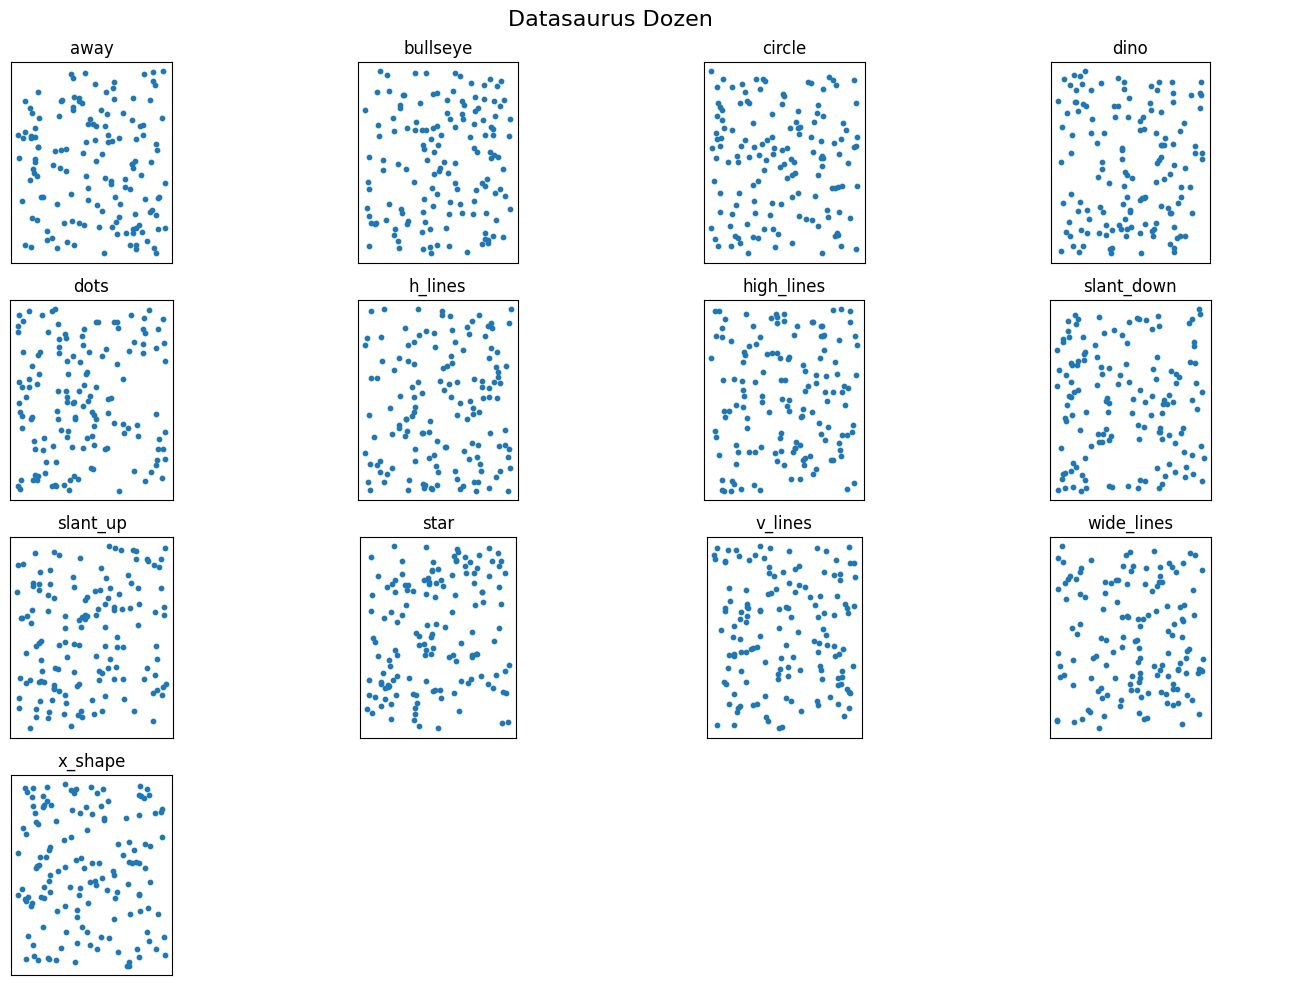

In [37]:
# plot all datasets in a grid
datasets = df["dataset"].unique()
n_plots = len(datasets)
ncols = 4
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, datasets):
    subset = df[df["dataset"] == name]
    ax.scatter(subset["x"], subset["y"], s=10)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

# hide leftover subplots
for ax in axes[n_plots:]:
    ax.axis("off")

plt.suptitle("Datasaurus Dozen", fontsize=16)
plt.tight_layout()
plt.show()

### Reflection

The summary statistics may look similar across datasets, but the plots can be very different.

This is why EDA should always include both:
- numerical summaries
- visual inspection